In [1]:
import os
import random
import datetime
import pickle

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import kagglehub

AUTOTUNE = tf.data.AUTOTUNE

SEEDS = [42, 123, 2024, 3407, 777]

BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 5
IMAGE_SIZE = (224, 224)
LEARNING_RATE = 1e-5
FINE_TUNE_LAYERS = 20


2026-05-10 16:49:54.790185: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778431794.976551      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778431795.027151      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778431795.453743      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778431795.453788      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778431795.453791      23 computation_placer.cc:177] computation placer alr

In [2]:
dataset_path = kagglehub.dataset_download("faysalmiah1721758/potato-dataset")

DATASET_DIR = dataset_path

class_names = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

NUM_CLASSES = len(class_names)

print("Dataset directory:", DATASET_DIR)
print("Detected classes:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("Number of classes:", NUM_CLASSES)

assert NUM_CLASSES == 3, f"Expected 3 classes, but found {NUM_CLASSES}"


Dataset directory: /kaggle/input/datasets/faysalmiah1721758/potato-dataset
Detected classes:
0: Potato___Early_blight
1: Potato___Late_blight
2: Potato___healthy
Number of classes: 3


In [3]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

file_paths = []
labels = []

for label_index, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_DIR, class_name)

    for fname in os.listdir(class_dir):
        if fname.lower().endswith(valid_extensions):
            file_paths.append(os.path.join(class_dir, fname))
            labels.append(label_index)

file_paths = np.array(file_paths)
labels = np.array(labels)

print("Total images:", len(labels))

unique, counts = np.unique(labels, return_counts=True)
print("\nClass distribution:")
for idx, count in zip(unique, counts):
    print(f"{class_names[idx]}: {count}")


Total images: 2152

Class distribution:
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152


In [4]:
def load_dataset_effnet(file_paths, labels, augment=False, shuffle=True, seed=None):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    def process(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])

        image = tf.image.resize(image, IMAGE_SIZE)
        image = tf.cast(image, tf.float32)

        if augment:
            image = tf.image.random_flip_left_right(image)
            image = tf.image.random_brightness(image, max_delta=25.5)
            image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
            image = tf.clip_by_value(image, 0.0, 255.0)

        image = preprocess_input(image)
        label = tf.one_hot(label, depth=NUM_CLASSES)

        return image, label

    ds = ds.map(process, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(file_paths),
            seed=seed,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds


In [5]:
def build_efficientnet_b0(num_classes=3, input_shape=(224, 224, 3)):
    inputs = tf.keras.Input(shape=input_shape)

    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    backbone.trainable = True

    for layer in backbone.layers[:-FINE_TUNE_LAYERS]:
        layer.trainable = False

    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="EfficientNetB0_3class_finetuned"
    )

    return model


In [6]:
def count_model_parameters(model):
    total_params = model.count_params()
    trainable_params = np.sum([
        np.prod(v.shape) for v in model.trainable_weights
    ])
    non_trainable_params = np.sum([
        np.prod(v.shape) for v in model.non_trainable_weights
    ])

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Non-trainable parameters: {non_trainable_params:,}")

    return total_params, trainable_params, non_trainable_params


In [7]:
def run_single_seed(seed):
    print("\n" + "=" * 70)
    print(f"Running seed: {seed}")
    print("=" * 70)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    X_train, X_temp, y_train, y_temp = train_test_split(
        file_paths,
        labels,
        test_size=0.20,
        stratify=labels,
        random_state=seed
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=seed
    )

    print(f"Train: {len(X_train)}")
    print(f"Validation: {len(X_val)}")
    print(f"Test: {len(X_test)}")

    class_weight_vals = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUM_CLASSES),
        y=y_train
    )
    class_weight = dict(enumerate(class_weight_vals))

    print("Class weights:", class_weight)

    train_ds = load_dataset_effnet(X_train, y_train, augment=True, shuffle=True, seed=seed)
    val_ds = load_dataset_effnet(X_val, y_val, augment=False, shuffle=False, seed=seed)
    test_ds = load_dataset_effnet(X_test, y_test, augment=False, shuffle=False, seed=seed)

    model = build_efficientnet_b0(num_classes=NUM_CLASSES)

    if seed == SEEDS[0]:
        count_model_parameters(model)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    os.makedirs("models", exist_ok=True)
    os.makedirs("history", exist_ok=True)

    run_name = f"EfficientNetB0_3class_seed_{seed}"

    model_path = f"models/{run_name}.keras"
    history_path = f"history/{run_name}_history.pkl"
    plot_path = f"history/{run_name}_accuracy_loss.png"
    cm_path = f"history/{run_name}_confusion_matrix.png"

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor="val_loss",
        save_best_only=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stop, checkpoint],
        class_weight=class_weight
    )

    with open(history_path, "wb") as f:
        pickle.dump(history.history, f)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    y_true = []
    y_pred = []

    for images, batch_labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(batch_labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True
    )

    print(f"\nSeed {seed} Test Accuracy: {test_acc:.4f}")
    print(f"Seed {seed} Test Loss: {test_loss:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    ))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        xticks_rotation=45
    )
    plt.title(f"Confusion Matrix: Seed {seed}")
    plt.tight_layout()
    plt.savefig(cm_path, dpi=300)
    plt.show()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy - Seed {seed}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss - Seed {seed}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.show()

    return {
        "seed": seed,
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "macro_precision": report_dict["macro avg"]["precision"],
        "macro_recall": report_dict["macro avg"]["recall"],
        "macro_f1": report_dict["macro avg"]["f1-score"],
        "weighted_precision": report_dict["weighted avg"]["precision"],
        "weighted_recall": report_dict["weighted avg"]["recall"],
        "weighted_f1": report_dict["weighted avg"]["f1-score"],
        "model_path": model_path,
        "history_path": history_path,
        "plot_path": plot_path,
        "confusion_matrix_path": cm_path
    }



Running seed: 42
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}


I0000 00:00:1778431820.810983      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 4,053,414
Trainable parameters: 1,354,803
Non-trainable parameters: 2,698,611.0
Epoch 1/50


I0000 00:00:1778431839.307461      66 service.cc:152] XLA service 0x79faf8002090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778431839.307520      66 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778431841.781560      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-10 16:50:47.560415: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 16:50:47.767732: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778431855.632840      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proc

53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4283 - loss: 1.0854

2026-05-10 16:51:04.094939: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 16:51:04.304239: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


54/54 ━━━━━━━━━━━━━━━━━━━━ 62s 583ms/step - accuracy: 0.4306 - loss: 1.0832 - val_accuracy: 0.5116 - val_loss: 0.9652
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.6298 - loss: 0.8645 - val_accuracy: 0.7674 - val_loss: 0.7637
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.7761 - loss: 0.7640 - val_accuracy: 0.8372 - val_loss: 0.6199
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8380 - loss: 0.5850 - val_accuracy: 0.8930 - val_loss: 0.5121
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8809 - loss: 0.5137 - val_accuracy: 0.9302 - val_loss: 0.4309
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8988 - loss: 0.4357 - val_accuracy: 0.9395 - val_loss: 0.3685
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9080 - loss: 0.3708 - val_accuracy: 0.9535 - val_loss: 0.3175
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9357 - loss: 0.3239 - val_accuracy: 0.9581 - val_loss: 

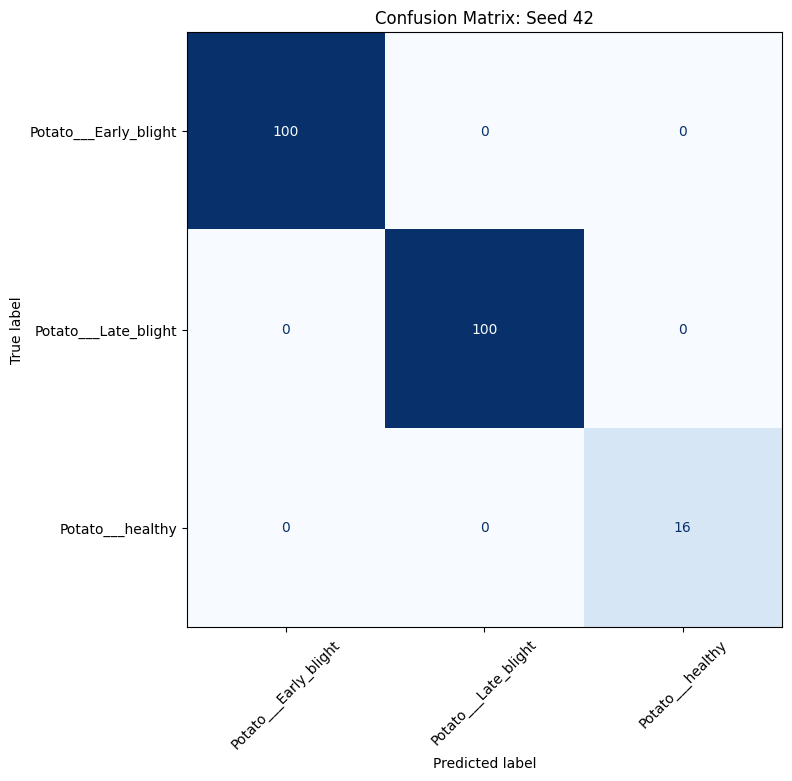

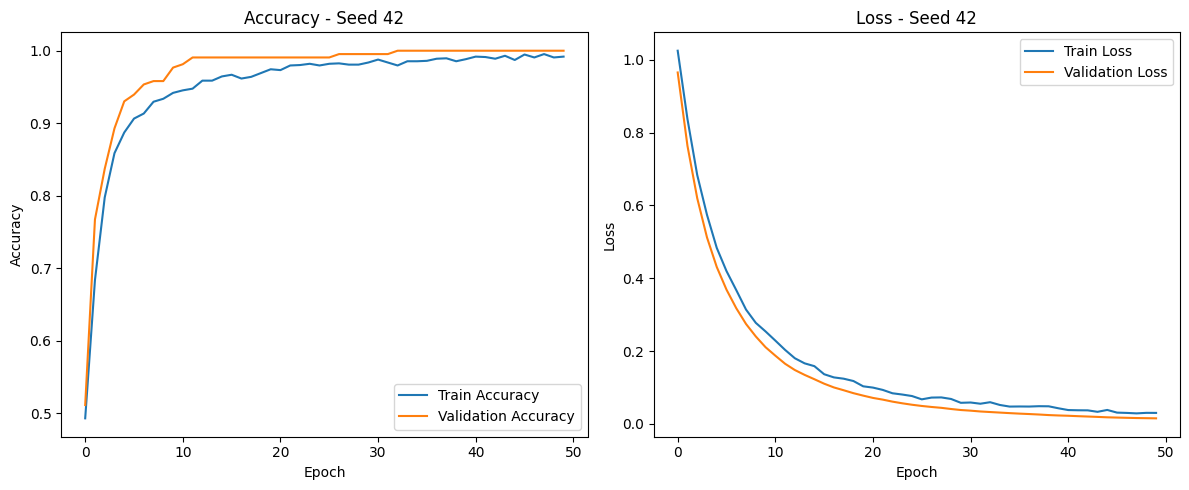


Running seed: 123
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 507ms/step - accuracy: 0.3794 - loss: 1.0732 - val_accuracy: 0.4186 - val_loss: 1.0546
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.5827 - loss: 0.8757 - val_accuracy: 0.6884 - val_loss: 0.8483
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.7420 - loss: 0.7308 - val_accuracy: 0.8372 - val_loss: 0.6769
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8306 - loss: 0.5917 - val_accuracy: 0.9023 - val_loss: 0.5507
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8718 - loss: 0.5088 - val_accuracy: 0.9163 - val_loss: 0.4558
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9029 - loss: 0.4193 - val_accuracy: 0.9256 - val_loss: 0.3825
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accura

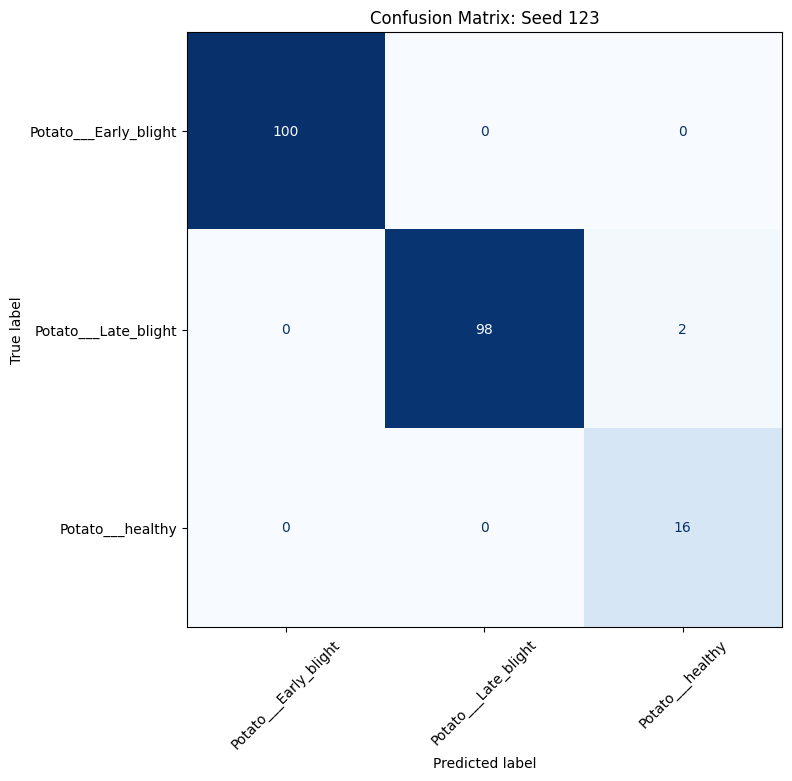

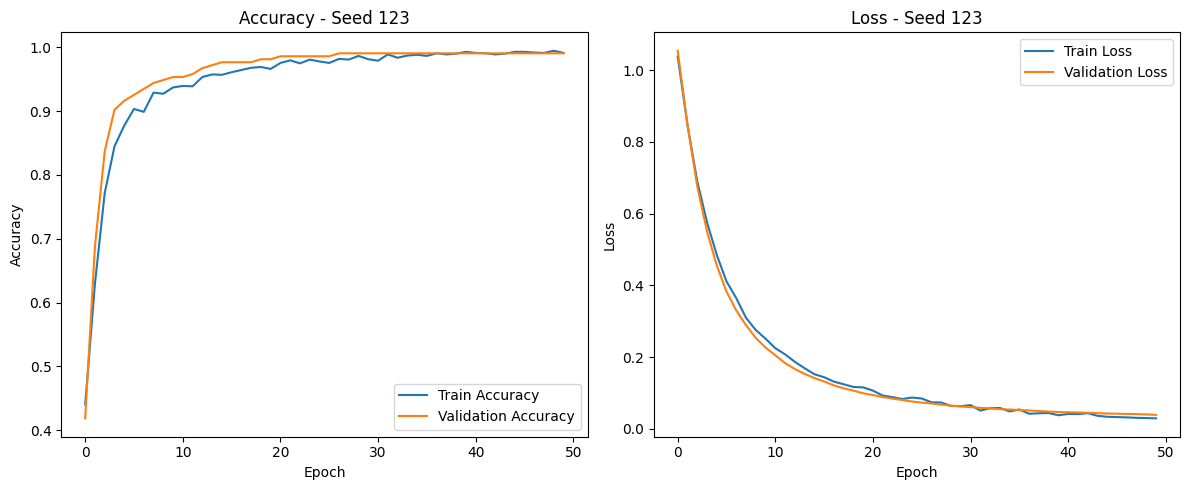


Running seed: 2024
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 52s 500ms/step - accuracy: 0.4022 - loss: 1.1108 - val_accuracy: 0.5163 - val_loss: 1.0263
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.6095 - loss: 0.8436 - val_accuracy: 0.6698 - val_loss: 0.8189
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.7797 - loss: 0.7111 - val_accuracy: 0.8093 - val_loss: 0.6575
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8464 - loss: 0.6044 - val_accuracy: 0.8744 - val_loss: 0.5449
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8608 - loss: 0.4880 - val_accuracy: 0.9023 - val_loss: 0.4589
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9076 - loss: 0.4085 - val_accuracy: 0.9209 - val_loss: 0.3955
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accur

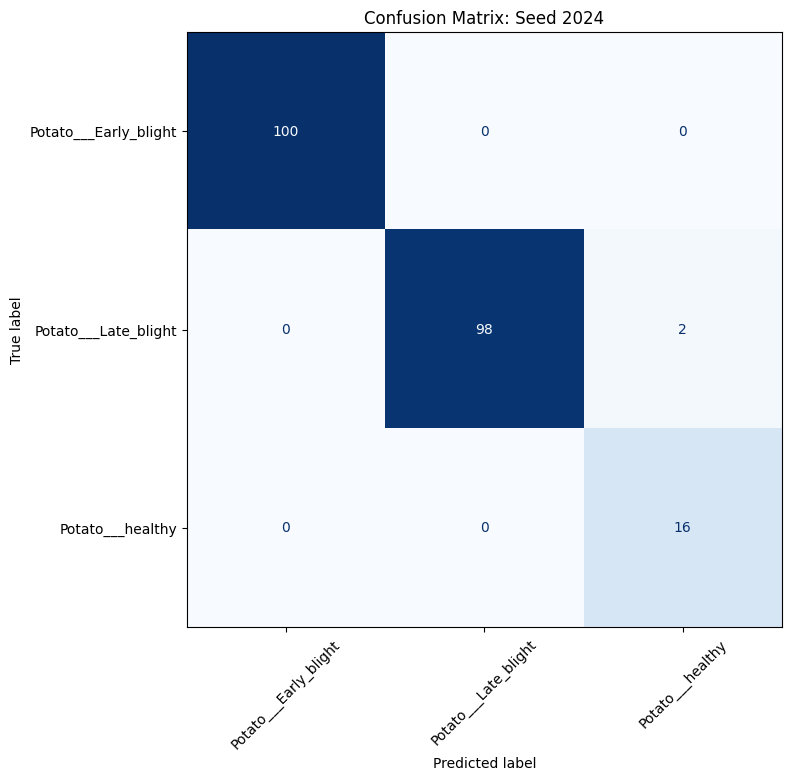

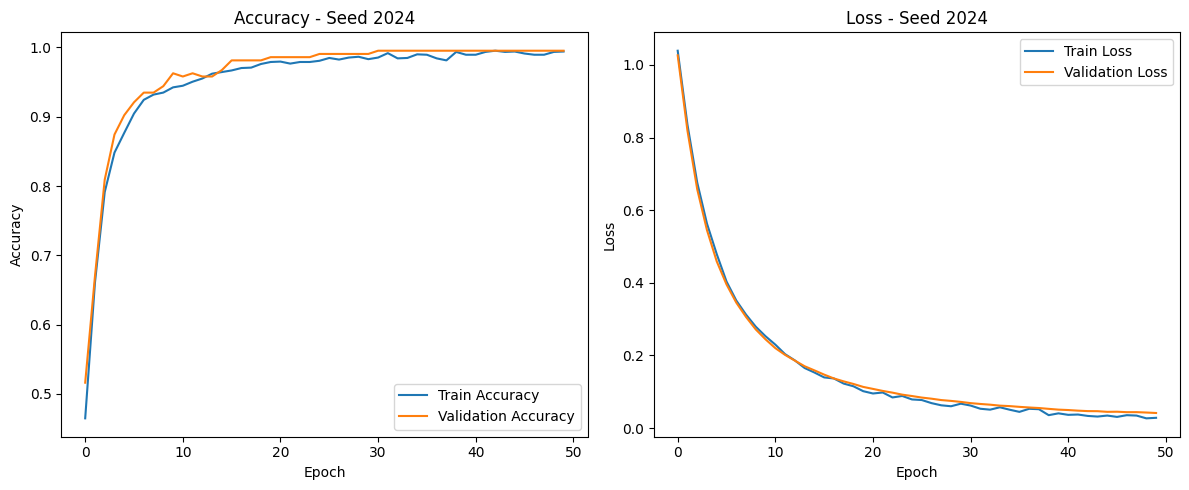


Running seed: 3407
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 503ms/step - accuracy: 0.2454 - loss: 1.1682 - val_accuracy: 0.3721 - val_loss: 1.0761
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.4745 - loss: 0.9502 - val_accuracy: 0.5860 - val_loss: 0.8990
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.6798 - loss: 0.8016 - val_accuracy: 0.7721 - val_loss: 0.7317
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.7684 - loss: 0.6646 - val_accuracy: 0.8326 - val_loss: 0.6042
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8292 - loss: 0.5495 - val_accuracy: 0.8558 - val_loss: 0.5096
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8707 - loss: 0.4743 - val_accuracy: 0.8651 - val_loss: 0.4358
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accur

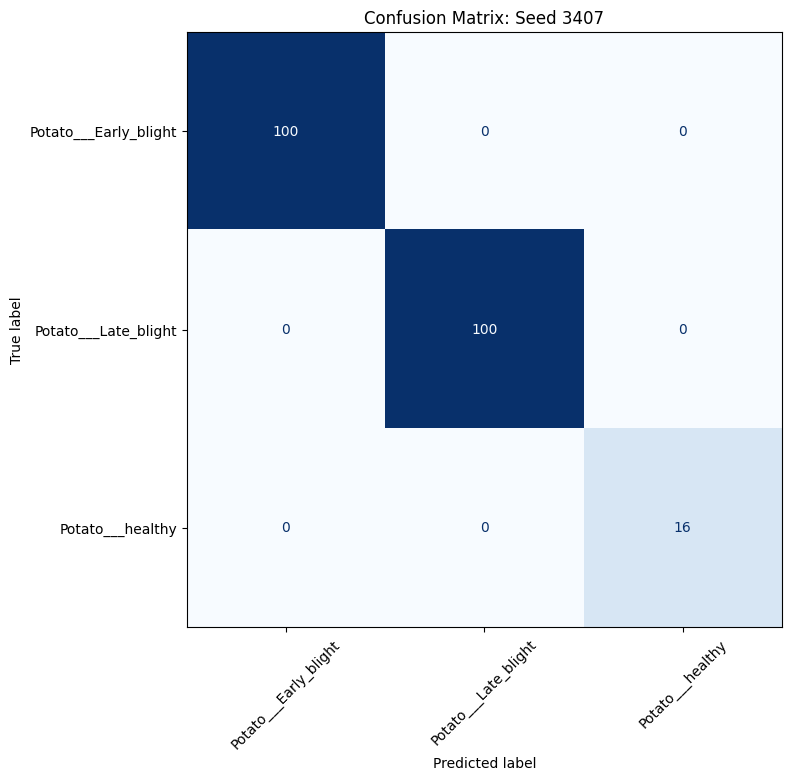

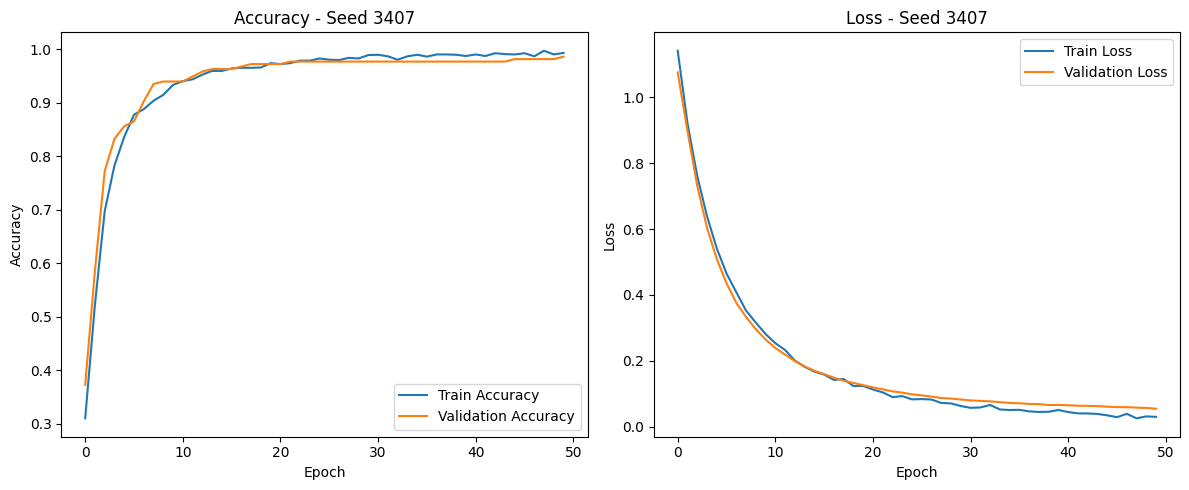


Running seed: 777
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 510ms/step - accuracy: 0.4244 - loss: 1.0650 - val_accuracy: 0.5860 - val_loss: 0.9152
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.6654 - loss: 0.8770 - val_accuracy: 0.7860 - val_loss: 0.7453
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.7863 - loss: 0.6990 - val_accuracy: 0.8512 - val_loss: 0.6196
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8233 - loss: 0.6086 - val_accuracy: 0.8698 - val_loss: 0.5232
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8707 - loss: 0.5239 - val_accuracy: 0.8977 - val_loss: 0.4503
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8850 - loss: 0.4348 - val_accuracy: 0.9070 - val_loss: 0.3914
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accura

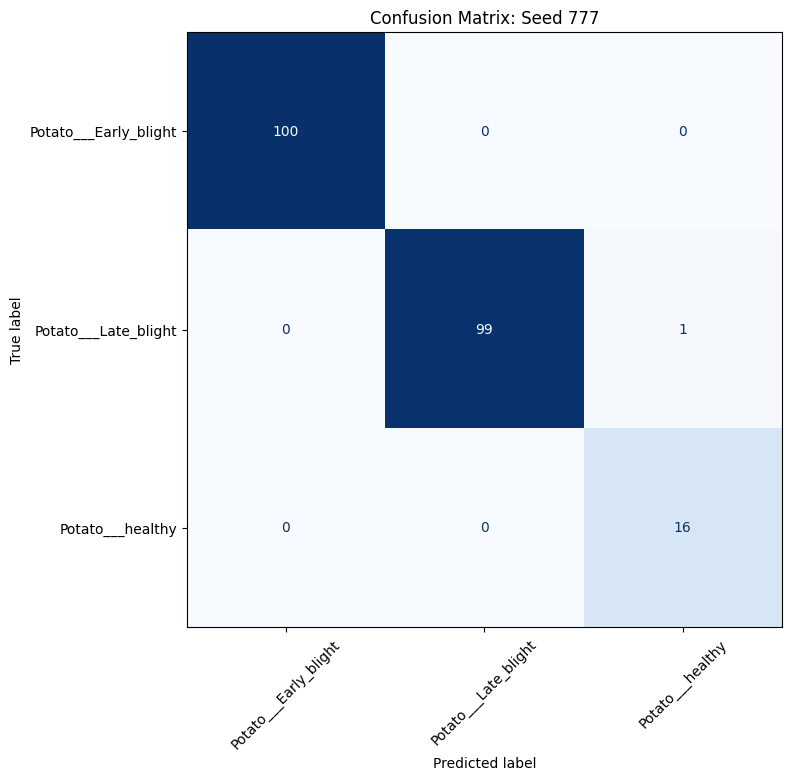

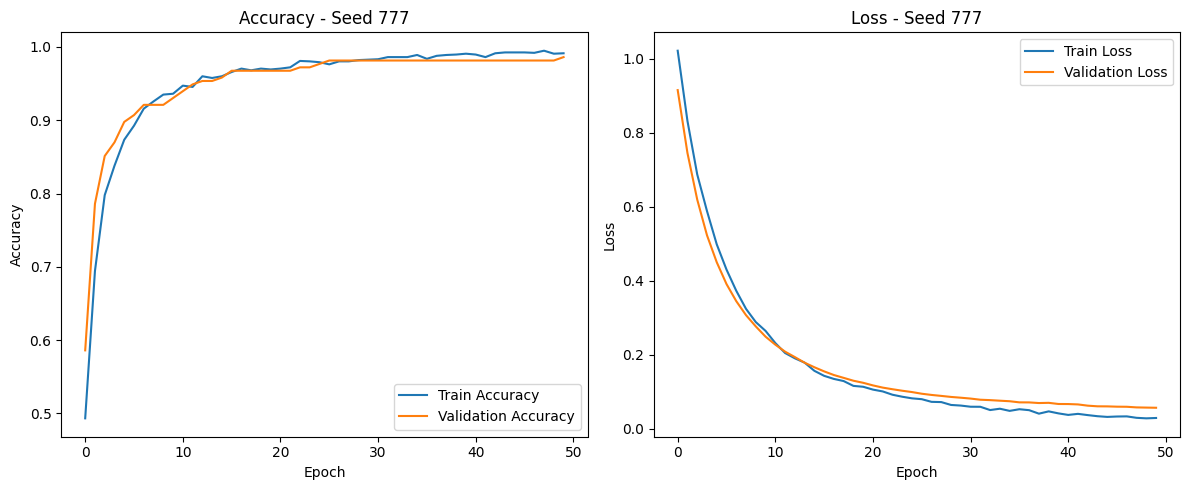


All seed results:
{'seed': 42, 'test_accuracy': 1.0, 'test_loss': 0.032727159559726715, 'macro_precision': 1.0, 'macro_recall': 1.0, 'macro_f1': 1.0, 'weighted_precision': 1.0, 'weighted_recall': 1.0, 'weighted_f1': 1.0, 'model_path': 'models/EfficientNetB0_3class_seed_42.keras', 'history_path': 'history/EfficientNetB0_3class_seed_42_history.pkl', 'plot_path': 'history/EfficientNetB0_3class_seed_42_accuracy_loss.png', 'confusion_matrix_path': 'history/EfficientNetB0_3class_seed_42_confusion_matrix.png'}
{'seed': 123, 'test_accuracy': 0.9907407164573669, 'test_loss': 0.03215691074728966, 'macro_precision': 0.9629629629629629, 'macro_recall': 0.9933333333333333, 'macro_f1': 0.9770251534957417, 'weighted_precision': 0.9917695473251029, 'weighted_recall': 0.9907407407407407, 'weighted_f1': 0.990966307959772, 'model_path': 'models/EfficientNetB0_3class_seed_123.keras', 'history_path': 'history/EfficientNetB0_3class_seed_123_history.pkl', 'plot_path': 'history/EfficientNetB0_3class_seed_123

In [8]:
all_results = []

for seed in SEEDS:
    result = run_single_seed(seed)
    all_results.append(result)

print("\nAll seed results:")
for result in all_results:
    print(result)


In [9]:
metrics = [
    "test_accuracy",
    "test_loss",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1"
]

print("\nMulti-seed summary:")
print("=" * 70)

for metric in metrics:
    values = np.array([result[metric] for result in all_results])
    mean_value = np.mean(values)
    std_value = np.std(values)

    print(f"{metric}: {mean_value:.4f} ± {std_value:.4f}")



Multi-seed summary:
test_accuracy: 0.9954 ± 0.0041
test_loss: 0.0346 ± 0.0114
macro_precision: 0.9813 ± 0.0166
macro_recall: 0.9967 ± 0.0030
macro_f1: 0.9885 ± 0.0103
weighted_precision: 0.9958 ± 0.0037
weighted_recall: 0.9954 ± 0.0041
weighted_f1: 0.9955 ± 0.0040


In [10]:
results_df = pd.DataFrame(all_results)
results_df.to_csv("EfficientNetB0_3class_multiseed_results.csv", index=False)

print("Saved multi-seed results to EfficientNetB0_3class_multiseed_results.csv")
results_df


Saved multi-seed results to EfficientNetB0_3class_multiseed_results.csv


,seed,test_accuracy,test_loss,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,model_path,history_path,plot_path,confusion_matrix_path
0,42,1.000000,0.032727,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,models/EfficientNetB0_3class_seed_42.keras,history/EfficientNetB0_3class_seed_42_history.pkl,history/EfficientNetB0_3class_seed_42_accuracy...,history/EfficientNetB0_3class_seed_42_confusio...
1,123,0.990741,0.032157,0.962963,0.993333,0.977025,0.991770,0.990741,0.990966,models/EfficientNetB0_3class_seed_123.keras,history/EfficientNetB0_3class_seed_123_history...,history/EfficientNetB0_3class_seed_123_accurac...,history/EfficientNetB0_3class_seed_123_confusi...
2,2024,0.990741,0.056537,0.962963,0.993333,0.977025,0.991770,0.990741,0.990966,models/EfficientNetB0_3class_seed_2024.keras,history/EfficientNetB0_3class_seed_2024_histor...,history/EfficientNetB0_3class_seed_2024_accura...,history/EfficientNetB0_3class_seed_2024_confus...
3,3407,1.000000,0.023773,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,models/EfficientNetB0_3class_seed_3407.keras,history/EfficientNetB0_3class_seed_3407_histor...,history/EfficientNetB0_3class_seed_3407_accura...,history/EfficientNetB0_3class_seed_3407_confus...
4,777,0.995370,0.027913,0.980392,0.996667,0.988224,0.995643,0.995370,0.995429,models/EfficientNetB0_3class_seed_777.keras,history/EfficientNetB0_3class_seed_777_history...,history/EfficientNetB0_3class_seed_777_accurac...,history/EfficientNetB0_3class_seed_777_confusi...
